In [84]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import nnls
import sys      


In [85]:
X_train_rough = np.load('data/X_train_rough.npy')
X_train_np = np.load('data/X_train_np.npy')
y_train_np = np.load('data/y_train_np.npy')
labels_list = np.load('data/labels_list.npy', allow_pickle=True)


In [87]:
plt.ioff()
wavelengths = np.linspace(1550, 1565, 1500)

In [ ]:
# # the difference operator
# # want it to be smooth, and rough line
# # means adjacent indices have huge absolute jumps
# # this is matrix of -1 and 1 on diagonal, so $(x_{i+1} - x_i)$
# # so dont solve Tx = y, optimize it via Ridge Regression, and want x >= 0
# # $$\min_{x \ge 0} \left( ||Tx - y||_2^2 + \alpha ||Lx||_2^2 \right)$$
# # \alpha ||Lx||_2^2 \right)$$ smoothness, penalize big jumps, alpha is how much we care about this
# # this good for broad, for sparse, it spreads out large penalities

calibration_matrix = scipy.io.loadmat("/Users/jatinvirmatharoo/Documents/Spectrometer URA/transmission_matrices/Matrix_calabration_Dis7.mat")['mat2']

def build_L(n):
    L = np.zeros((n-1, n))
    for i in range(n-1):
        L[i, i] = -1
        L[i, i+1] = 1
    return L

# # 5000000 means we care a lot
# alpha = 5000000.0
alpha = 50000
T = calibration_matrix
L = build_L(1500)
# # T = [T, a*L]^t, y = [y 0]^t
T_aug = np.vstack([T, np.sqrt(alpha) * L])

# X_train_rough = []
# for i in range(3000):
#     if i % 1 == 0:
#         print(f"{i}/3000 done...")
#     y_aug = np.concatenate([X_train_np[i], np.zeros(1499)])
#     x, _ = nnls(T_aug, y_aug)
#     x = np.clip(x, 0, 1)
#     X_train_rough.append(x)

# # X_train_rough will now hold the noisy spectrum after reg nnls
# X_train_rough = np.array(X_train_rough)

# # X_train_rough = X_rough_guess.detach().cpu().numpy()


In [102]:
# np.save('data/X_train_rough.npy', X_train_rough)
# np.save('data/X_train_np.npy', X_train_np)
# np.save('data/y_train_np.npy', y_train_np)
# np.save('data/labels_list.npy', np.array(labels_list))



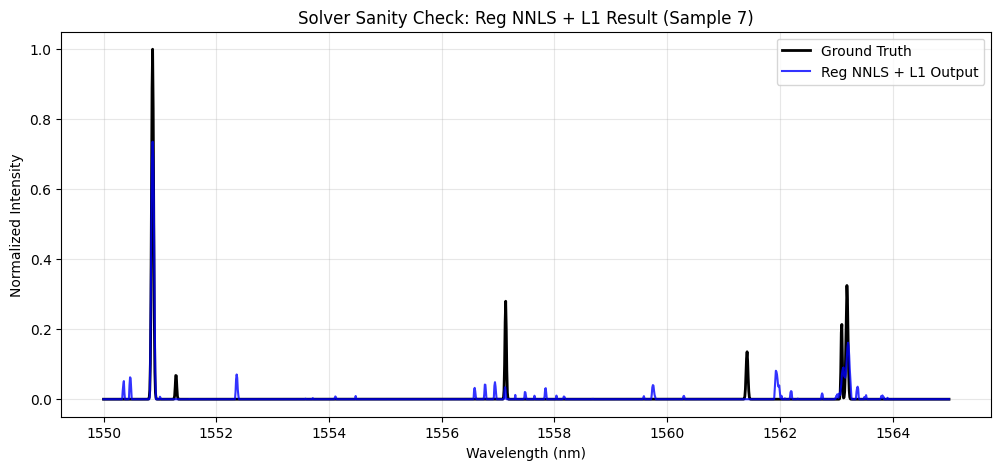

In [103]:
# plot one graph to see
sample_idx = 7
plt.figure(figsize=(12, 5))
plt.plot(wavelengths, y_train_np[sample_idx], label="Ground Truth", color="black", linewidth=2)
plt.plot(wavelengths, X_train_rough[sample_idx], label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=True)



In [104]:
# Neural Network #1 to denoise and predict better

# now build neural network to clear up this rough mess, MLP
# need to experiemnt with different node sizes
# we have 25, they had 108
# Input: 1500 nodes
# Layer 1 : 32 nodes
# Layer 2 : 32 nodes
# OutputL 1500 nodes

# fully connected multi layer perceptron

class SolverNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    # define layers

    self.layer1 = nn.Linear(1500, 128)
    self.layer2 = nn.Linear(128, 128)
    self.layer3 = nn.Linear(128, 1500)

    # activation function
    self.SiLU = nn.SiLU()

  def forward(self, x):
    x = self.layer1(x)
    x = self.SiLU(x)

    x = self.layer2(x)
    x = self.SiLU(x)

    x = self.layer3(x)

    return x


In [105]:
# Generate PyTorch Dataset

class SolverDataset(Dataset):
  def __init__(self, X, y, labels):
    self.X = torch.tensor(X, dtype= torch.float32)
    self.y = torch.tensor(y, dtype= torch.float32)
    self.labels = labels

  # used to know when one epoch is done
  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx], self.labels[idx]


In [106]:
# create training and validation set

split = int(0.8 * len(X_train_rough))
X_train = X_train_rough[:split]
X_val = X_train_rough[split:]
y_train = y_train_np[:split]
y_val = y_train_np[split:]
labels_train = labels_list[:split]
labels_val = labels_list[split:]

train_dataset = SolverDataset(X_train, y_train, labels_train)
val_dataset = SolverDataset(X_val, y_val, labels_val)



In [107]:
# load the data

batch_size = 50
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [108]:
model = SolverNetwork()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# higher = smoother
smoothness_lambda = 0

def combined_loss(predictions, targets):
    mse = loss_function(predictions, targets)
    smoothness = torch.mean((predictions[:, 1:] - predictions[:, :-1]) ** 2)
    return mse + smoothness_lambda * smoothness


In [109]:
epochs = 30
label_names = ['generate_sparse_spectrum', 'generate_narrow_absorption', 'generate_broad_emission', 'generate_broad_absorption']
for epoch in range(epochs):

  train_loss = 0.0
  model.train()
  for batch in train_loader:
    x = batch[0]
    y = batch[1]

    predictions = model(x)
    loss = combined_loss(predictions, y)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  model.eval()
  with torch.no_grad():
    val_loss = 0.0
    per_type_loss = {name: [] for name in label_names}
    for i, batch in enumerate(val_loader):
      x = batch[0]
      y = batch[1]
      labels_batch = batch[2]

      predictions = model(x)
      loss = combined_loss(predictions, y) 

      val_loss += loss.item()

      sample_losses = ((predictions - y) **2).mean(dim = 1)
      for j, lbl in enumerate(labels_batch):
        per_type_loss[lbl].append(sample_losses[j].item())



  
  avg_loss = train_loss / len(train_loader)

  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss}, Val Loss: {val_loss/len(val_loader)}")
  for name in label_names:
        losses = per_type_loss[name]
        if losses:
            print(f"  {name.replace('generate_', '')}: {np.mean(losses):.6f}")






Epoch 1/30, Train Loss: 0.10013531563648333, Val Loss: 0.035816460071752466
  sparse_spectrum: 0.006403
  narrow_absorption: 0.042414
  broad_emission: 0.052078
  broad_absorption: 0.044168
Epoch 2/30, Train Loss: 0.031847543587597706, Val Loss: 0.022986362377802532
  sparse_spectrum: 0.005647
  narrow_absorption: 0.026118
  broad_emission: 0.034185
  broad_absorption: 0.027053
Epoch 3/30, Train Loss: 0.01897885826959585, Val Loss: 0.01656598225235939
  sparse_spectrum: 0.005206
  narrow_absorption: 0.017902
  broad_emission: 0.023529
  broad_absorption: 0.020279
Epoch 4/30, Train Loss: 0.015674231748562306, Val Loss: 0.014158239588141441
  sparse_spectrum: 0.004823
  narrow_absorption: 0.012746
  broad_emission: 0.023288
  broad_absorption: 0.016263
Epoch 5/30, Train Loss: 0.01308927465773498, Val Loss: 0.015246640347565213
  sparse_spectrum: 0.004531
  narrow_absorption: 0.023410
  broad_emission: 0.019456
  broad_absorption: 0.014478
Epoch 6/30, Train Loss: 0.012459890150542682, Val

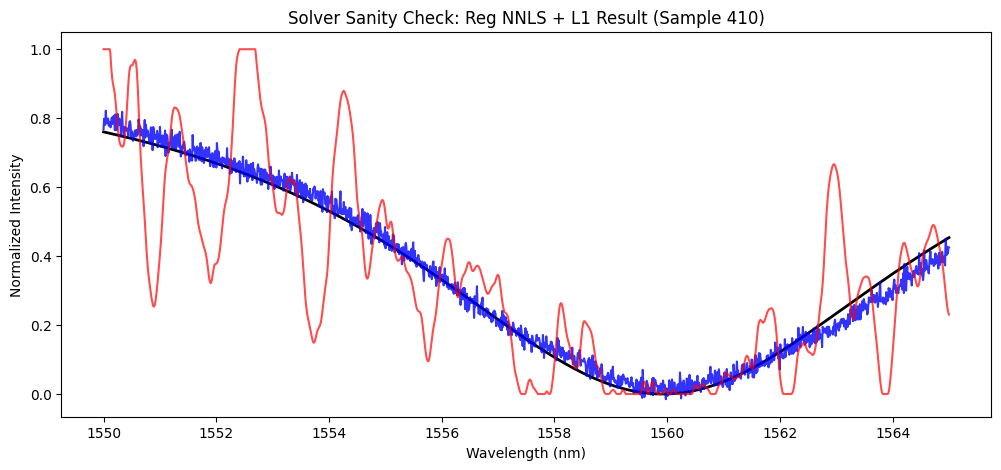

In [110]:
# compare one

sample_idx = 410
val_x = X_val[sample_idx]
val_t = y_val[sample_idx]

val_x = torch.tensor(val_x, dtype=torch.float32)
val_t = torch.tensor(val_t, dtype=torch.float32)

val_x = val_x.unsqueeze(0)
val_t = val_t.unsqueeze(0)

model.eval()

with torch.no_grad():
  val_pred = model(val_x)
  val_pred = val_pred.squeeze(0).numpy()
  val_t = val_t.squeeze(0).numpy()

  plt.figure(figsize=(12, 5))

  plt.plot(wavelengths, val_t, label="Ground Truth", color="black", linewidth=2)
  plt.plot(wavelengths, val_pred, label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
  plt.plot(wavelengths, X_val[sample_idx], label="Solver output", color="red", alpha=0.7)
  plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
  plt.xlabel("Wavelength (nm)")
  plt.ylabel("Normalized Intensity")
  plt.show()


